In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [2]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [5]:
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0001'
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0013'
# img_name =  '20260717T120225_pA_Activin_D4_48hr_W0027'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']

img_name = '20260521T171725_pA-BMP4_G3_44hr_induction_W0001'
channel_names = ['T', 'BMP4', 'CDX2', 'Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(8460, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,T_mean,BMP4_mean,CDX2_mean,Hoechst_mean,T+,BMP4+,CDX2+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,12.914561,28.009627,831.0,108.769553,105.801519,0.488736,0.974209,0.842799,35.141412,30.658481,...,0.932883,1.146222,120.766546,117.476534,222.641396,623.598075,False,False,False,True
2,3.857143,52.584416,154.0,48.142136,48.323124,0.831432,0.980892,0.810526,19.251009,10.696384,...,0.828744,1.799768,122.350649,117.551948,211.422078,586.337662,False,False,False,True
3,8.926136,88.539773,352.0,72.526912,71.441341,0.774091,0.953930,0.698413,26.922827,17.044157,...,0.866669,1.579593,123.528409,118.522727,226.752841,683.954545,False,False,False,True


In [6]:
if_cols = [c+'_mean' for c in channel_names if c != 'Hoechst']
clipped_df = cell_df[['centroid_y', 'centroid_x']]

for c in channel_names:
    clipped_df[c+'_mean'] = cell_df[c+'_mean'] * cell_df[c+'+']
    
print(clipped_df.shape)
clipped_df.head(3)

(8460, 6)


,centroid_y,centroid_x,T_mean,BMP4_mean,CDX2_mean,Hoechst_mean
cell_id,,,,,,
1,12.914561,28.009627,0.0,0.0,0.0,623.598075
2,3.857143,52.584416,0.0,0.0,0.0,586.337662
3,8.926136,88.539773,0.0,0.0,0.0,683.954545


### Analysis

In [7]:
# # toggle to see what it looks like scaled
# scaled_df = pd.read_csv(f'../data/training/{img_name}_scaled.csv',index_col=0)
# for c in scaled_df.columns:
#     cell_df[c] = scaled_df[c].values

# cell_df.head(3)

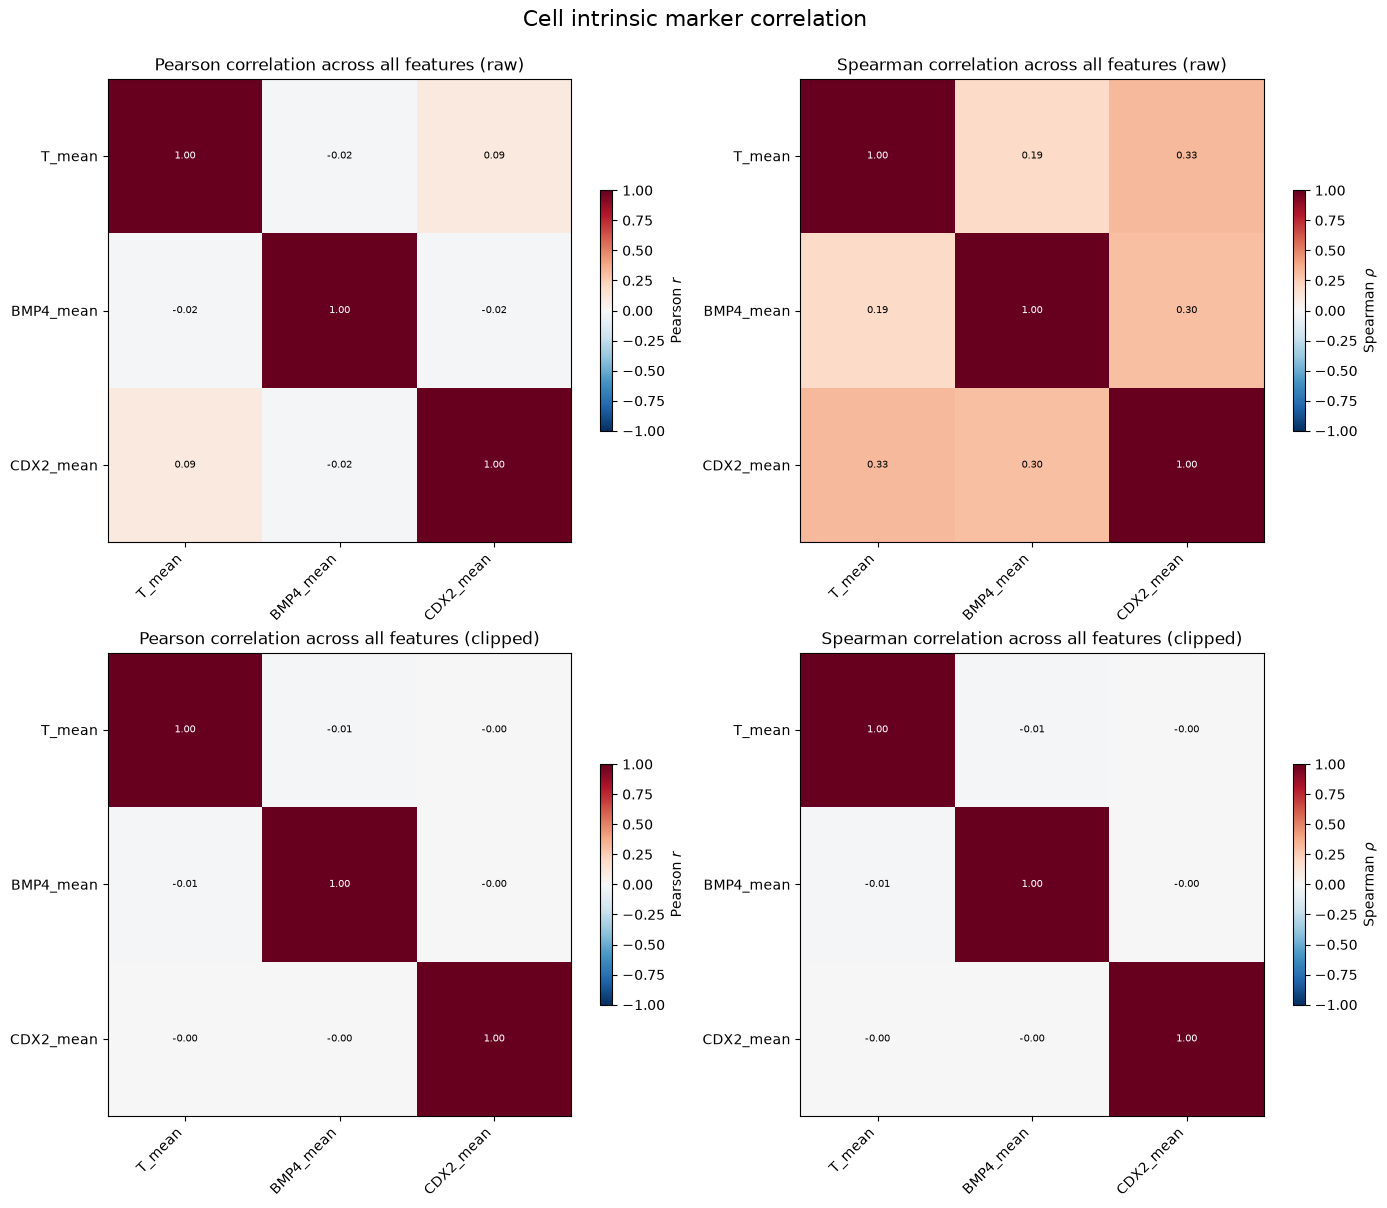

In [8]:
import matplotlib.pyplot as plt
from tools.morphology import plot_correlation_heatmap

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

_, corr_cell_p = plot_correlation_heatmap(
    cell_df, if_cols, title='Pearson correlation across all features (raw)', corr_type='pearson', ax=axes[0, 0]
)
_, corr_cell_s = plot_correlation_heatmap(
    cell_df, if_cols, title='Spearman correlation across all features (raw)', corr_type='spearman', ax=axes[0, 1]
)
_, corr_if_p = plot_correlation_heatmap(
    clipped_df, if_cols, title='Pearson correlation across all features (clipped)', corr_type='pearson', ax=axes[1, 0]
)
_, corr_if_s = plot_correlation_heatmap(
    clipped_df, if_cols, title='Spearman correlation across all features (clipped)', corr_type='spearman', ax=axes[1, 1]
)

plt.suptitle('Cell intrinsic marker correlation', fontsize=16, y=1)
fig.tight_layout()
plt.show()


In [9]:
from scipy.spatial import KDTree

N = len(cell_df)
K = 10

centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

# Query K+1 neighbors (since centroids are the query points, index 0 is always self)
tree = KDTree(centroids)
distances, indices = tree.query(centroids, k=K + 1)

# Exclude self-matches (first column)
src = np.repeat(np.arange(N), K)
dst = indices[:, 1:].flatten()

# Symmetrize/deduplicate (equivalent to the union of forward and backward edges)
pairs = set(zip(src, dst))
symmetric_pairs = pairs | {(j, i) for (i, j) in pairs}

edge_index_np = np.array(sorted(symmetric_pairs), dtype=np.int64).T
edge_dist_np = np.linalg.norm(centroids[edge_index_np[0]] - centroids[edge_index_np[1]], axis=1).astype(np.float32)

edge_index = torch.from_numpy(edge_index_np)
edge_attr = torch.from_numpy(edge_dist_np).unsqueeze(-1)

print(f'{N} cells, {edge_index.shape[1]} symmetrized edges (k={K} spatial nearest neighbors)')


8460 cells, 92866 symmetrized edges (k=10 spatial nearest neighbors)


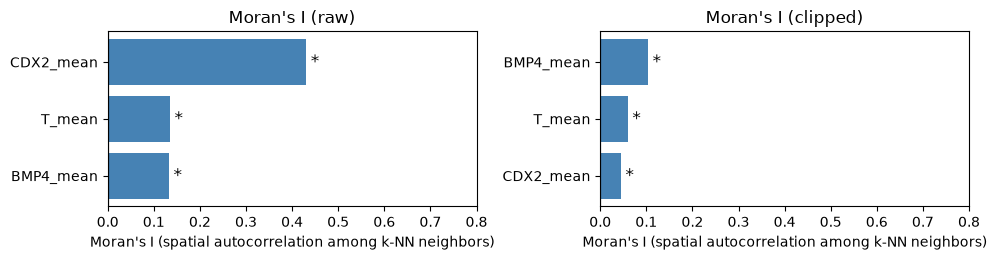

,morans_i,null_mean,null_std,p_value
feature,,,,
CDX2_mean,0.430517,0.000685,0.004186,0.01
T_mean,0.134911,-0.000584,0.004704,0.01
BMP4_mean,0.132767,0.000123,0.005191,0.01


,morans_i,null_mean,null_std,p_value
feature,,,,
BMP4_mean,0.103554,0.000013,0.005051,0.01
T_mean,0.059668,-0.000850,0.004812,0.01
CDX2_mean,0.044720,0.000045,0.004850,0.02


In [10]:
from tools.morphology import morans_i_table, plot_morans_i

morans_raw = morans_i_table(cell_df, if_cols, edge_index)
morans_clipped = morans_i_table(clipped_df, if_cols, edge_index)

fig, axes = plt.subplots(1, 2, figsize=(10, 0.4 * len(if_cols) + 1.5))
plot_morans_i(morans_raw, title="Moran's I (raw)", ax=axes[0])
plot_morans_i(morans_clipped, title="Moran's I (clipped)", ax=axes[1])

axes[0].set_xlim(0, 0.8)
axes[1].set_xlim(0, 0.8)

fig.tight_layout()
plt.show()

display(morans_raw)
display(morans_clipped)


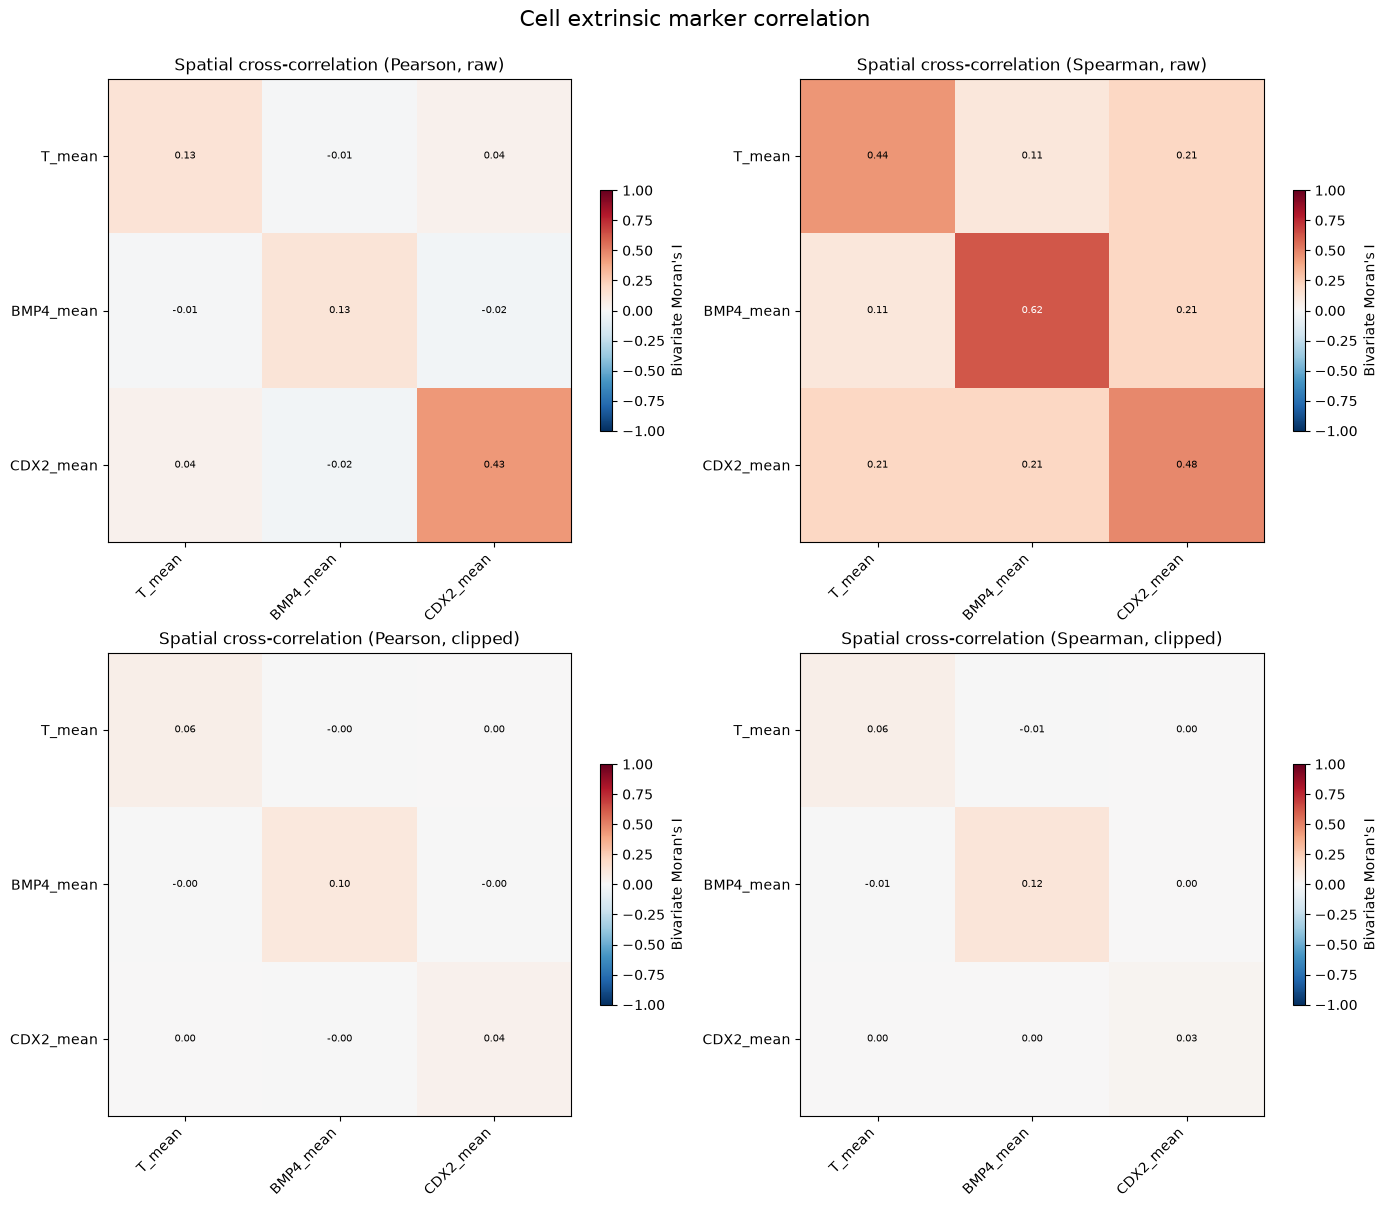

In [11]:
from tools.morphology import plot_spatial_cross_correlation, top_correlated_pairs

# not as a replacement for either.
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

_, spatial_corr_raw_p = plot_spatial_cross_correlation(
    cell_df, if_cols, title='Spatial cross-correlation (Pearson, raw)', corr_type='pearson', ax=axes[0, 0], edge_index=edge_index
)
_, spatial_corr_raw_s = plot_spatial_cross_correlation(
    cell_df, if_cols, title='Spatial cross-correlation (Spearman, raw)', corr_type='spearman', ax=axes[0, 1], edge_index=edge_index
)
_, spatial_corr_clipped_p = plot_spatial_cross_correlation(
    clipped_df, if_cols, title='Spatial cross-correlation (Pearson, clipped)', corr_type='pearson', ax=axes[1, 0], edge_index=edge_index
)
_, spatial_corr_clipped_s = plot_spatial_cross_correlation(
    clipped_df, if_cols, title='Spatial cross-correlation (Spearman, clipped)', corr_type='spearman', ax=axes[1, 1], edge_index=edge_index
)

plt.suptitle("Cell extrinsic marker correlation", fontsize=16, y=1)
fig.tight_layout()

In [12]:
# raw (unfiltered) Cellpose label mask -- cells_mask_from_labels restricts to just
# the cell_ids that survived filtering (cell_df.index), regardless of what other
# labels the raw mask contains
out = tiff.imread(f'../data/stitched/{img_name}.tif')
label_mask = np.load(f'../data/stitched/{img_name}.npy')
cell_mask = np.where(label_mask > 1, True, False)
print(out.shape, label_mask.shape, cell_mask.shape)

(4, 1998, 1998) (1998, 1998) (1998, 1998)


In [13]:
from tools.morphology import cells_mask_from_labels
from tools.features import radius_total_signal

RADIUS = 75  # px -- disk radius to total up fluorescence within, centered on each cell

patch_df_masked = radius_total_signal(
    out, cell_df, radius=RADIUS, channel_names=channel_names,
    cell_mask=cell_mask, use_mask=True,
)

# Per-channel positivity gate: a cell's pixels only contribute to channel c's total if
# that cell is IF-positive for c (clipped_df[f'{c}_mean'] != 0) -- an IF-negative cell is
# excluded entirely from c's neighborhood sum (not just zeroed at its own location), and
# different channels can gate out different cells, so this needs one mask per channel
# rather than the single shared `cell_mask` above.
channel_masks_clipped = {
    c: cells_mask_from_labels(label_mask, clipped_df.index[clipped_df[f'{c}_mean'] != 0])
    for c in channel_names
}
patch_df_clipped = radius_total_signal(
    out, clipped_df, radius=RADIUS, channel_names=channel_names,
    cell_mask=channel_masks_clipped, use_mask=True,
)

patch_cols = [c + '_total' for c in channel_names if c != 'Hoechst']

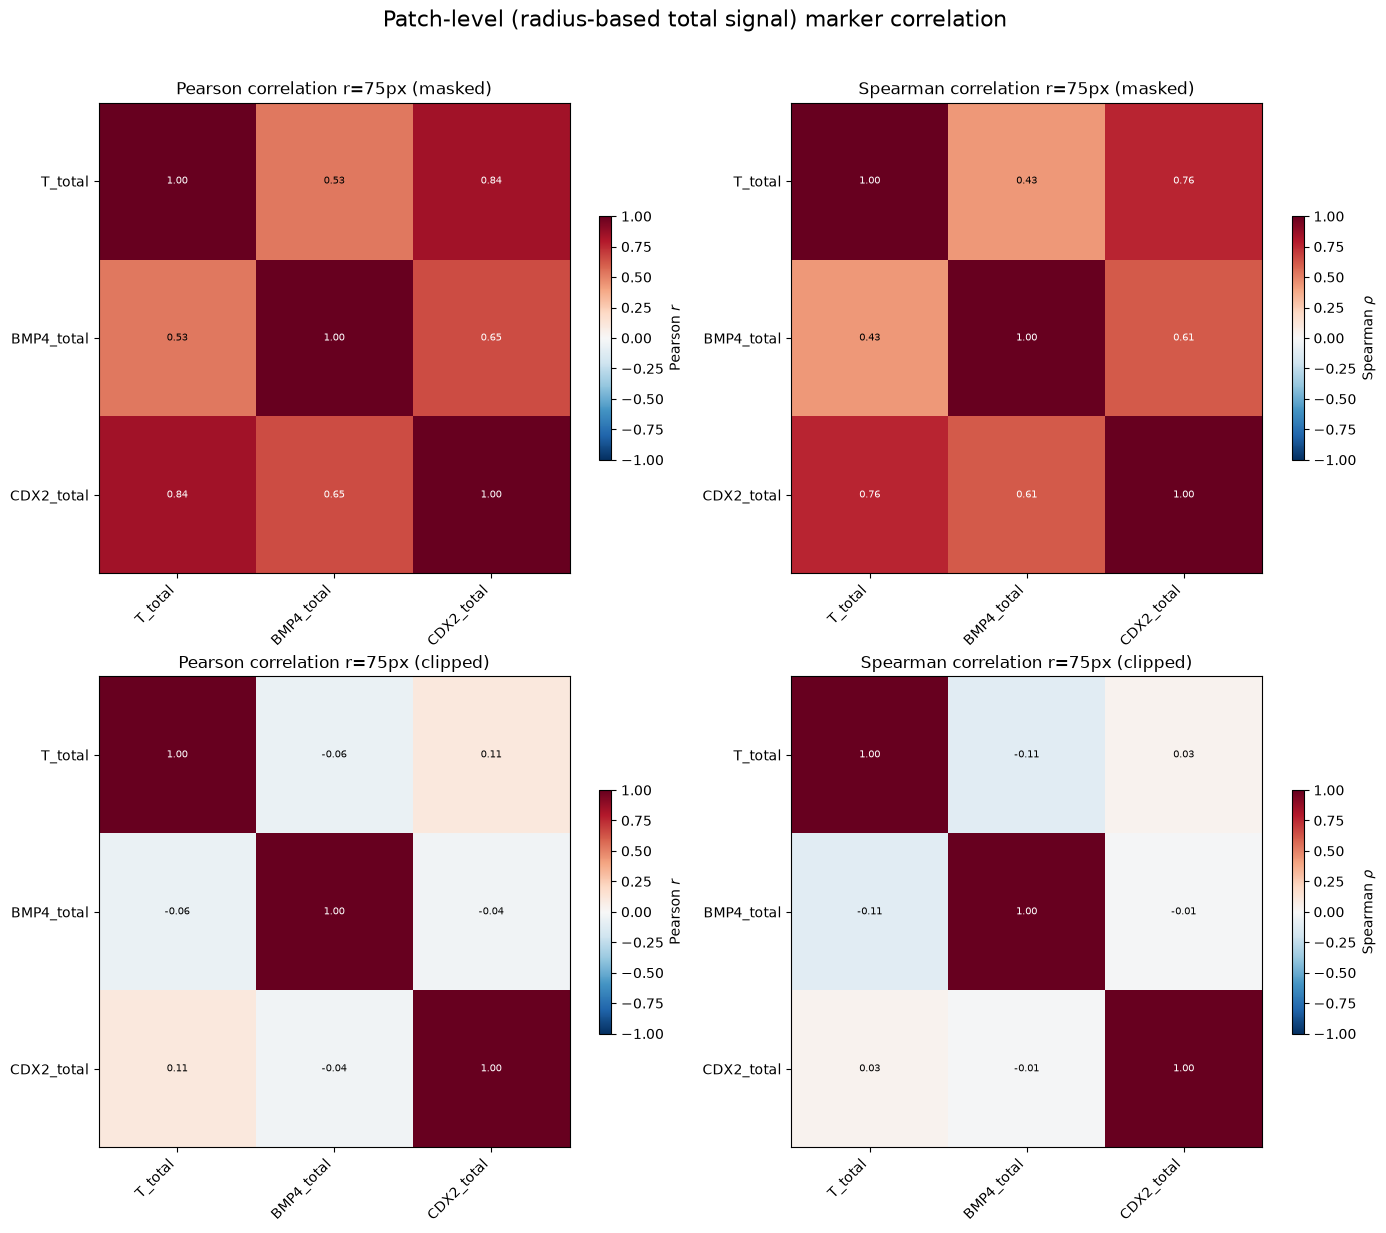

In [14]:
from tools.morphology import plot_correlation_heatmap

# Same plot_correlation_heatmap as the cell-intrinsic marker correlation above, just
# fed patch-level total signal (patch_df) instead of each cell's own mean intensity.
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

_, corr_patch_p = plot_correlation_heatmap(
    patch_df_masked, patch_cols, title=f'Pearson correlation r={RADIUS}px (masked)',
    corr_type='pearson', ax=axes[0],
)
_, corr_patch_s = plot_correlation_heatmap(
    patch_df_masked, patch_cols, title=f'Spearman correlation r={RADIUS}px (masked)',
    corr_type='spearman', ax=axes[1],
)
_, corr_patch_p = plot_correlation_heatmap(
    patch_df_clipped, patch_cols, title=f'Pearson correlation r={RADIUS}px (clipped)',
    corr_type='pearson', ax=axes[2],
)
_, corr_patch_s = plot_correlation_heatmap(
    patch_df_clipped, patch_cols, title=f'Spearman correlation r={RADIUS}px (clipped)',
    corr_type='spearman', ax=axes[3],
)


plt.suptitle('Patch-level (radius-based total signal) marker correlation', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

### Prediction

In [15]:
cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')

# cell_df['Sox17+'] = True
# cell_df['Activin+'] = True
# cell_df['FoxA2+'] = True

fig_dir = f'../results/figures/{img_name}'
os.makedirs(fig_dir, exist_ok=True)

In [19]:
cell_df.head(2)

,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,aspect_ratio,T_mean,BMP4_mean,CDX2_mean,Hoechst_mean,T+,BMP4+,CDX2+,Hoechst+,local_density
cell_id,,,,,,,,,,,,,,,,,,,,,
1,12.914561,28.009627,831.0,108.769553,105.801519,0.488736,0.974209,0.842799,35.141412,30.658481,...,1.146222,120.766546,117.476534,222.641396,623.598075,False,False,False,True,4.0
2,3.857143,52.584416,154.0,48.142136,48.323124,0.831432,0.980892,0.810526,19.251009,10.696384,...,1.799768,122.350649,117.551948,211.422078,586.337662,False,False,False,True,6.0


In [20]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_loss_curves, local_density
from models.gnn import build_prediction_data, train_neighbor_predictor, NeighborIFPredictor, predict_df as gnn_predict_df, border_mask, save_model
from models.gat import NeighborIFPredictorGAT

PRED_RADIUS = 200  # px -- create a graph (every pair within radius is connected), NOT k-NN
DENSITY_RADIUS = 50 # compute number of cells within this radius as feature
GLOBAL_X_COLS = ['BMP4_mean', 'local_density']
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler;
SEED = 0

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
cell_df['local_density'] = local_density(centroids, radius=DENSITY_RADIUS)

border_radius = max(PRED_RADIUS, DENSITY_RADIUS) 
is_border = border_mask(centroids, out.shape[1:], border_radius)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {border_radius}px of the border -- excluded as targets')

train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

pred_data = build_prediction_data(
    cell_df, if_cols, radius=PRED_RADIUS, global_x_cols=GLOBAL_X_COLS, train_idx=train_idx, scaling=SCALING,
    # local_density has neither a real "background" floor nor a right-skewed tail the
    # way an intensity channel does -- subtracting a background just clips a chunk of
    # its real variation to an identical value, and log1p only makes its (already
    # roughly symmetric, sometimes left-skewed) distribution more skewed, not less.
    no_background_cols=['local_density'],
    no_transform_cols=['local_density'],
)
print('neighbor_x_cols (seen only via neighbors):', pred_data['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', pred_data['global_x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells, {pred_data['edge_index'].shape[1]} directed edges (radius={PRED_RADIUS}px)")

2980 / 8460 cells within 200px of the border -- excluded as targets
neighbor_x_cols (seen only via neighbors): ['T_mean', 'BMP4_mean', 'CDX2_mean']
global_x_cols (seen directly, incl. self): ['BMP4_mean', 'local_density']
y_cols (predicted): ['T_mean', 'CDX2_mean']
8460 cells, 2096668 directed edges (radius=200px)


In [22]:
# check if the dynamic range is good enough for prediction
data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
data['BMP4_mean'] = pred_data['x_global'][:, 0]
data['local_density'] = pred_data['x_global'][:, 1]
data['centroid_x'] = cell_df['centroid_x'].values
data['centroid_y'] = cell_df['centroid_y'].values
print(data.shape)
data.tail(2)

(8460, 6)


,T_mean,CDX2_mean,BMP4_mean,local_density,centroid_x,centroid_y
8458,-0.797467,-0.892541,-0.486586,-3.577806,1843.164384,1995.205479
8459,-0.797467,-0.892541,-0.486586,-2.737241,1994.400000,1995.550000


In [23]:
data.to_csv(f'../data/training/{img_name}_scaled.csv')

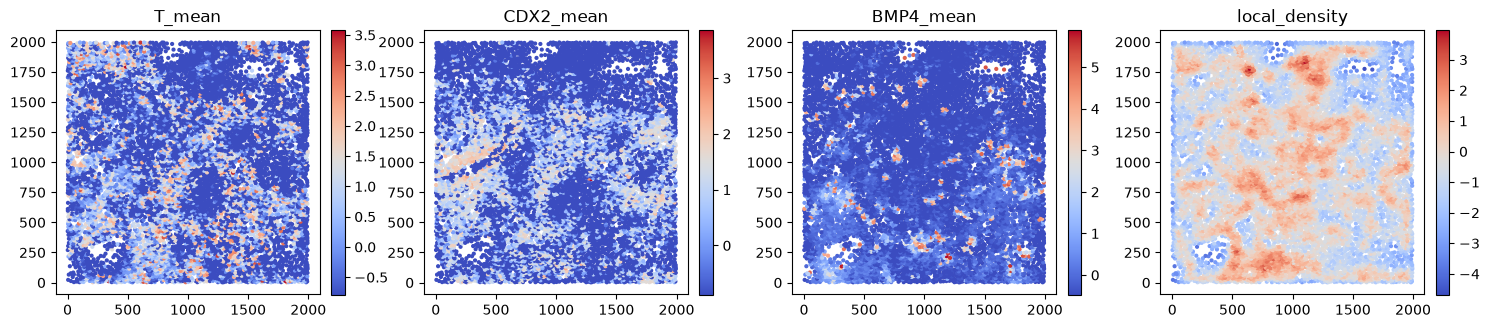

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs = axs.flatten()

for i, col in enumerate(cols):
    ax = axs[i]
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=4
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)

fig.tight_layout()
plt.savefig(f'{fig_dir}/features.png', dpi=300)
plt.show()

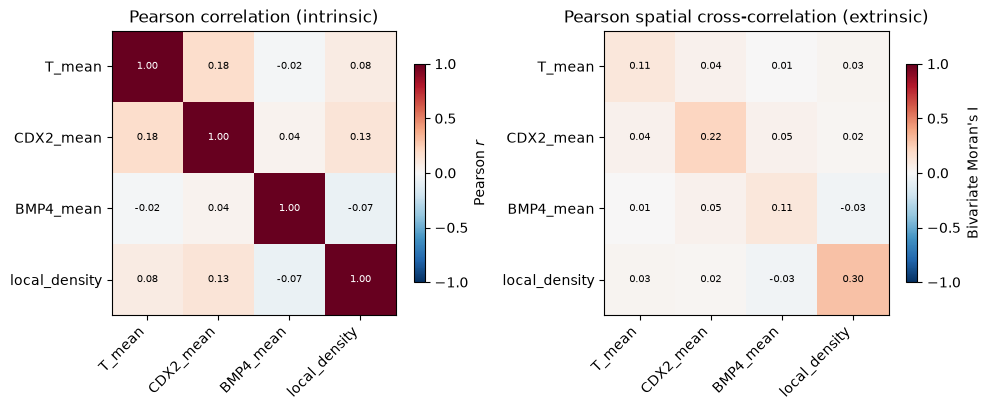

In [25]:
from tools.morphology import plot_correlation_heatmap, plot_spatial_cross_correlation

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_correlation_heatmap(data, cols, title=f'Pearson correlation (intrinsic)', corr_type='pearson', ax=axs[0])
plot_spatial_cross_correlation(data, cols, title='Pearson spatial cross-correlation (extrinsic)', corr_type='pearson', edge_index=pred_data['edge_index'], ax=axs[1])
plt.tight_layout()
plt.savefig(f'{fig_dir}/features_corr.png', dpi=300)


GNN:   0%|          | 0/1500 [00:00<?, ?it/s]

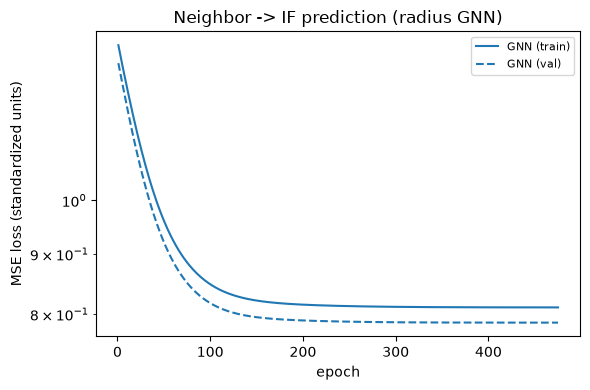

,R2,MAE
feature,,
T_mean,0.179200,0.750877
CDX2_mean,0.267397,0.712528


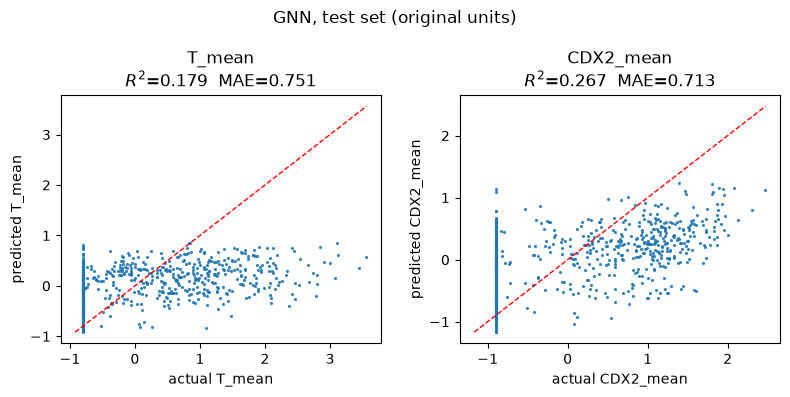

Saved model to ../results/models/20260521T171725_pA-BMP4_G3_44hr_induction_W0001_gnn.pt


In [26]:
GNN_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
)

torch.manual_seed(SEED)
gnn_model = NeighborIFPredictor(**GNN_KWARGS)
gnn_history = train_neighbor_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN', 
    epochs=1500, lr=1e-3
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title='Neighbor -> IF prediction (radius GNN)')
plt.show()

# Original units (default) -- predict_df now returns (pred_df, true_df) together, both
# in the same units, same y_scaler=None toggle as models.cnn.predict_patch_df.
gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
display(gnn_r2)
fig_gnn_pred = plot_pred_vs_actual(gnn_true_test, gnn_pred_test, title='GNN, test set (original units)')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_gnn.pt', gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS,
)
print(f'Saved model to ../results/models/{img_name}_gnn.pt')

GAT:   0%|          | 0/1000 [00:00<?, ?it/s]

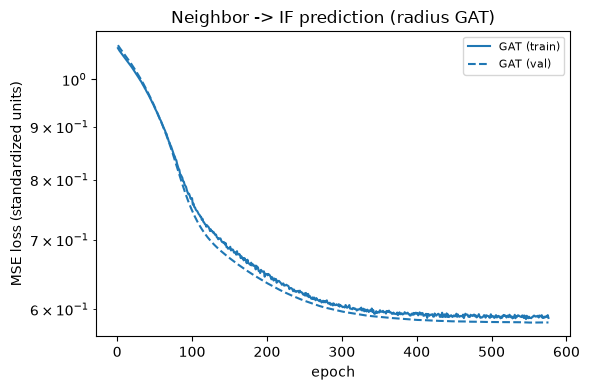

,R2,MAE
feature,,
T_mean,0.439322,0.609651
CDX2_mean,0.359637,0.642386


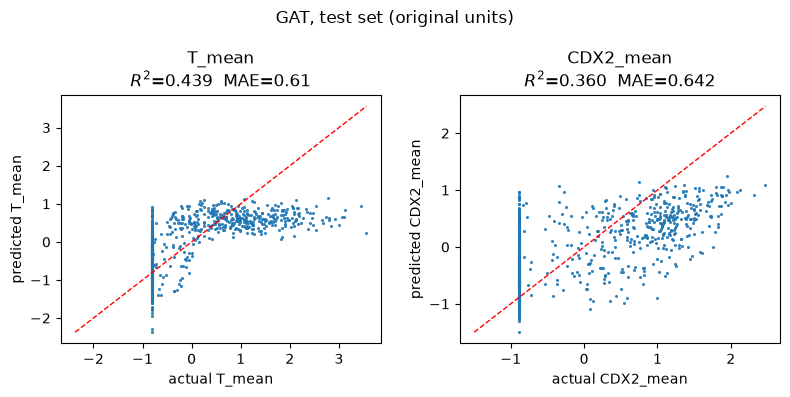

Saved model to ../results/models/20260521T171725_pA-BMP4_G3_44hr_induction_W0001_gat.pt


In [27]:
GAT_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
)

torch.manual_seed(SEED)
gat_model = NeighborIFPredictorGAT(**GAT_KWARGS)
gat_history = train_neighbor_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=1000, lr=1e-3
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title='Neighbor -> IF prediction (radius GAT)')
plt.show()

# Original units (default) -- predict_df now returns (pred_df, true_df) together, both
# in the same units, same y_scaler=None toggle as models.cnn.predict_patch_df.
gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
display(gat_r2)
fig_gat_pred = plot_pred_vs_actual(gat_true_test, gat_pred_test, title='GAT, test set (original units)')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_gat.pt', gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS,
)
print(f'Saved model to ../results/models/{img_name}_gat.pt')

In [28]:
comparison = pd.concat({'GNN (fixed weights)': gnn_r2, 'GAT (learned attention)': gat_r2}, axis=1)
display(comparison)

GNN (fixed weights)           GAT (learned attention)          
                           R2       MAE                      R2       MAE
feature                                                                  
T_mean               0.179200  0.750877                0.439322  0.609651
CDX2_mean            0.267397  0.712528                0.359637  0.642386

### Understanding the GAT: attention weights

`WeightedNeighborConv` (the fixed-weight GNN) weights every neighbor by a deterministic
function of distance alone -- there's nothing to "interpret" there beyond the decay
curve itself. `GATConv` (the GAT) instead LEARNS its neighbor weighting, so inspecting
those learned attention weights directly shows what the model actually uses, rather
than assuming distance is what matters.

`GATConv` hands back the exact per-edge attention coefficient via
`return_attention_weights=True` -- softmax-normalized so each cell's incoming
attention still sums to 1, same property as the fixed GNN's `edge_weight`, just
learned instead of fixed. Two things worth checking:
- **Attention vs. distance**: if attention just tracks the same exponential decay the
  fixed GNN assumes, geometry is doing all the work and the learned attention isn't
  adding anything beyond it. If it doesn't correlate with distance, the model has
  found something in the neighbor FEATURES themselves that geometry alone can't explain.
- **Per-cell attention map**: for one example cell, which of its neighbors does the
  model actually lean on -- the physically closest ones, or ones with a similar/
  dissimilar marker profile regardless of exact distance?

In [29]:
fig_dir

'../results/figures/20260521T171725_pA-BMP4_G3_44hr_induction_W0001'

In [ ]:
edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.NeighborRadiusGAT.attention_by_layer) --
# with num_layers > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x_neighbor'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One subplot for distance, one per neighbor marker, and one more for the CENTER cell's
# own value of whichever marker is BOTH a global_x_col and a neighbor_x_col (found
# dynamically -- not hardcoded to a specific channel name, since which markers are in
# play depends on GLOBAL_X_COLS/the experiment's panel) -- distinct from the
# neighbor-side panel for that same marker above, which is the NEIGHBORS' own values,
# not the center's. Same NORMALIZED (scaled) values the model itself sees, so the
# correlation reflects what the model actually looked at, not raw fluorescence's very
# different scale.
neighbor_cols = pred_data['neighbor_x_cols']
global_x_cols = pred_data['global_x_cols']
center_marker_col = next(c for c in global_x_cols if c in neighbor_cols)
center_marker_idx = global_x_cols.index(center_marker_col)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# neighbor_x_cols/global_x_cols values; deeper layers' attention operates on the
# embeddings that resulted from earlier layers, so a correlation there reflects an
# indirect/aggregate relationship with the raw marker, not a direct one.
n_panels = 1 + len(neighbor_cols) + 1
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px)')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(neighbor_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x_neighbor'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (neighbor, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

    ax = axes[layer_idx, -1]
    center_marker = pred_data['x_global'][dst, center_marker_idx].numpy()
    ax.scatter(center_marker, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(center_marker, layer_att.numpy())[0, 1]
    ax.set_xlabel(f'{center_marker_col} (center cell, scaled)')
    ax.set_title(f'layer {layer_idx}: {center_marker_col}, center (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and neighbor markers, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cells below use the FINAL layer's attention -- the one that most directly determines
# what reaches the prediction head.
att_weights = layer_attentions[-1]

In [ ]:
# One example (held-out test) cell: one attention-weight panel PER LAYER (positions are
# identical across layers -- only the coloring/attention values change, since layer 1's
# attention is a genuinely different, separately-learned quantity from layer 0's, see
# the "distance and neighbor markers, by layer" cell above), then one panel per neighbor
# marker (these don't depend on layer at all, so shown once rather than repeated).
example_cell_pos = test_idx[0]
mask_edges = (dst == example_cell_pos)
neighbor_pos = src[mask_edges].numpy()

n_layers = len(layer_attentions)
n_panels = n_layers + len(neighbor_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    neighbor_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=neighbor_att, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(neighbor_cols):
    ax = axes[n_layers + j]
    values = pred_data['x_neighbor'][neighbor_pos, j].numpy()
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. neighbor markers: cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example_cell.png', dpi=300, bbox_inches='tight')
plt.show()